# 07 — Model vs. USDA Ground Truth

Compares every `outputs/predictions.05_model*.csv` against USDA 2025 actuals.

## Forecast-date mapping

| Our label | USDA Period |
|---|---|
| `aug1` | `YEAR - AUG FORECAST` |
| `sep1` | `YEAR - SEP FORECAST` |
| `oct1` | *(no USDA analog — scored as NaN)* |
| `final` | `YEAR - NOV FORECAST` |
| `actual` | `YEAR` (true end-of-season) |

## Naming convention
Save each model run as `outputs/predictions.05_model{X}.{Y}.csv`  
(e.g. `predictions.05_model1.2.csv`). This notebook picks them all up automatically.

## USDA file
Place the static USDA QuickStats export at `data/raw/usda_2025_actuals.csv`  
and never modify it — it is ground truth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
USDA_PATH   = "../data/raw/usda_2025_actuals.csv"
PRED_GLOB   = "../outputs/predictions.05_model*.csv"
OUT_DIR     = Path("../outputs")

STATES = ['Colorado', 'Iowa', 'Missouri', 'Nebraska', 'Wisconsin']

# Maps USDA 'Period' values to our forecast_date labels.
# 'actual' is the true end-of-season YEAR value — useful as an upper-bound target.
PERIOD_MAP = {
    "YEAR - AUG FORECAST": "aug1",
    "YEAR - SEP FORECAST": "sep1",
    "YEAR - NOV FORECAST": "final",
    "YEAR":                "actual",
}

# Ordered for display — oct1 has no USDA ground truth.
SCORED_DATES  = ["aug1", "sep1", "final"]   # dates we can score
ALL_DATES     = ["aug1", "sep1", "oct1", "final"]  # dates we predict

In [2]:
# ── LOAD & PARSE USDA GROUND TRUTH ────────────────────────────────────────────
usda_raw = pd.read_csv(USDA_PATH)

usda = (
    usda_raw[
        (usda_raw['Program']   == 'SURVEY') &
        (usda_raw['Year']      == 2025) &
        (usda_raw['Data Item'] == 'CORN, GRAIN - YIELD, MEASURED IN BU / ACRE') &
        (usda_raw['Geo Level'] == 'STATE') &
        (usda_raw['State'].isin([s.upper() for s in STATES]))
    ]
    .copy()
)

usda['Value'] = pd.to_numeric(
    usda['Value'].astype(str).str.replace(',', ''), errors='coerce'
)
usda['forecast_date'] = usda['Period'].map(PERIOD_MAP)
usda = usda.dropna(subset=['forecast_date', 'Value'])
usda['state'] = usda['State'].str.title()   # 'IOWA' → 'Iowa'
usda = usda[['state', 'forecast_date', 'Value']].rename(columns={'Value': 'usda_yield'})

print(f"USDA ground truth — {len(usda)} rows")
print(usda.sort_values(['forecast_date', 'state']).to_string(index=False))

USDA ground truth — 20 rows
    state forecast_date  usda_yield
 Colorado        actual         133
     Iowa        actual         210
 Missouri        actual         185
 Nebraska        actual         194
Wisconsin        actual         188
 Colorado          aug1         118
     Iowa          aug1         222
 Missouri          aug1         191
 Nebraska          aug1         192
Wisconsin          aug1         185
 Colorado         final         130
     Iowa         final         216
 Missouri         final         178
 Nebraska         final         191
Wisconsin         final         183
 Colorado          sep1         126
     Iowa          sep1         219
 Missouri          sep1         184
 Nebraska          sep1         191
Wisconsin          sep1         184


In [3]:
# ── LOAD ALL MODEL PREDICTIONS ────────────────────────────────────────────────
pred_files = sorted(glob.glob(PRED_GLOB))

if not pred_files:
    raise FileNotFoundError(
        f"No files matching '{PRED_GLOB}'. "
        "Run a 05_model notebook first and save its output."
    )

print(f"Found {len(pred_files)} model version(s):")
for f in pred_files:
    print(f"  {Path(f).name}")

all_preds = []
for f in pred_files:
    df = pd.read_csv(f)
    df['model_version'] = Path(f).stem.replace('predictions.', '')
    all_preds.append(df)

preds = pd.concat(all_preds, ignore_index=True)
# Normalise state capitalisation coming out of the model CSVs
preds['state'] = preds['state'].str.title()
print(f"\nTotal prediction rows loaded: {len(preds)}")

Found 5 model version(s):
  predictions.05_model-2.csv
  predictions.05_model1.1.csv
  predictions.05_model1.2.csv
  predictions.05_model1.4.csv
  predictions.05_model1.5.csv

Total prediction rows loaded: 100


In [4]:
# ── MERGE PREDICTIONS WITH USDA ───────────────────────────────────────────────
# We merge on state + forecast_date.
# oct1 rows will carry NaN usda_yield — that is expected and correct.
# 'actual' rows from USDA (true end-of-season) are also joined for reference;
# they won't match any model forecast_date so appear only in the usda table.

merged = preds.merge(
    usda[usda['forecast_date'].isin(SCORED_DATES)],
    on=['state', 'forecast_date'],
    how='left'
)

# Also join the true end-of-season actual for a separate reference column
actuals = (
    usda[usda['forecast_date'] == 'actual']
    [['state', 'usda_yield']]
    .rename(columns={'usda_yield': 'usda_actual'})
)
merged = merged.merge(actuals, on='state', how='left')

merged['error']      = merged['predicted_yield'] - merged['usda_yield']
merged['abs_error']  = merged['error'].abs()
merged['pct_error']  = (merged['error'] / merged['usda_yield'] * 100).round(2)
merged['ci_covers']  = (
    (merged['usda_yield'] >= merged['ci_lower']) &
    (merged['usda_yield'] <= merged['ci_upper'])
)
merged['err_vs_actual'] = merged['predicted_yield'] - merged['usda_actual']

display_cols = [
    'model_version', 'state', 'forecast_date',
    'predicted_yield', 'usda_yield', 'error', 'pct_error', 'ci_covers',
    'usda_actual', 'err_vs_actual'
]
print("Full comparison (oct1 rows have NaN usda_yield — expected):")
print(
    merged[display_cols]
    .sort_values(['model_version', 'forecast_date', 'state'])
    .to_string(index=False)
)

Full comparison (oct1 rows have NaN usda_yield — expected):
model_version     state forecast_date  predicted_yield  usda_yield  error  pct_error  ci_covers  usda_actual  err_vs_actual
   05_model-2  Colorado          aug1           139.77       118.0  21.77      18.45      False          133           6.77
   05_model-2      Iowa          aug1           165.48       222.0 -56.52     -25.46      False          210         -44.52
   05_model-2  Missouri          aug1           161.31       191.0 -29.69     -15.54      False          185         -23.69
   05_model-2  Nebraska          aug1           174.42       192.0 -17.58      -9.16      False          194         -19.58
   05_model-2 Wisconsin          aug1           159.40       185.0 -25.60     -13.84      False          188         -28.60
   05_model-2  Colorado         final           142.76       130.0  12.76       9.82      False          133           9.76
   05_model-2      Iowa         final           162.95       216.0 -53.0

In [5]:
# ── SUMMARY: RMSE / MAE / CI COVERAGE PER MODEL × FORECAST DATE ───────────────
scored = merged.dropna(subset=['usda_yield'])  # exclude oct1

summary = (
    scored
    .groupby(['model_version', 'forecast_date'])
    .agg(
        rmse       = ('abs_error', lambda x: round(np.sqrt((x**2).mean()), 2)),
        mae        = ('abs_error', lambda x: round(x.mean(), 2)),
        ci_cov_pct = ('ci_covers', lambda x: round(x.mean() * 100, 1)),
        n_states   = ('abs_error', 'count'),
    )
    .reset_index()
)

# Reorder forecast_date for readability
cat_order = pd.CategoricalDtype(SCORED_DATES, ordered=True)
summary['forecast_date'] = summary['forecast_date'].astype(cat_order)
summary = summary.sort_values(['model_version', 'forecast_date'])

print("Summary — RMSE / MAE / CI coverage (%) per model × forecast date:")
print(summary.to_string(index=False))

out_path = OUT_DIR / "comparison_summary.csv"
summary.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

Summary — RMSE / MAE / CI coverage (%) per model × forecast date:
model_version forecast_date  rmse   mae  ci_cov_pct  n_states
   05_model-2          aug1 33.21 30.23         0.0         5
   05_model-2          sep1 31.64 28.11        20.0         5
   05_model-2         final 28.70 24.72         0.0         5
  05_model1.1          aug1 28.38 25.11         0.0         5
  05_model1.1          sep1 27.07 23.74         0.0         5
  05_model1.1         final 26.09 22.07         0.0         5
  05_model1.2          aug1 33.21 30.23         0.0         5
  05_model1.2          sep1 31.64 28.11        20.0         5
  05_model1.2         final 28.70 24.72         0.0         5
  05_model1.4          aug1  5.50  4.66       100.0         5
  05_model1.4          sep1  4.89  4.28        80.0         5
  05_model1.4         final  7.93  5.97        80.0         5
  05_model1.5          aug1 12.40  9.84        40.0         5
  05_model1.5          sep1 10.33  9.29        40.0         5
  05

In [6]:
# ── SUMMARY: OVERALL RMSE PER MODEL (across all scored dates) ─────────────────
overall = (
    scored
    .groupby('model_version')
    .agg(
        overall_rmse = ('abs_error', lambda x: round(np.sqrt((x**2).mean()), 2)),
        overall_mae  = ('abs_error', lambda x: round(x.mean(), 2)),
        ci_cov_pct   = ('ci_covers', lambda x: round(x.mean() * 100, 1)),
    )
    .reset_index()
    .sort_values('overall_rmse')
)

print("Overall ranking (lower RMSE = better):")
print(overall.to_string(index=False))

Overall ranking (lower RMSE = better):
model_version  overall_rmse  overall_mae  ci_cov_pct
  05_model1.4          6.25         4.97        86.7
  05_model1.5         11.00         9.50        33.3
  05_model1.1         27.19        23.64         0.0
   05_model-2         31.24        27.69         6.7
  05_model1.2         31.24        27.69         6.7


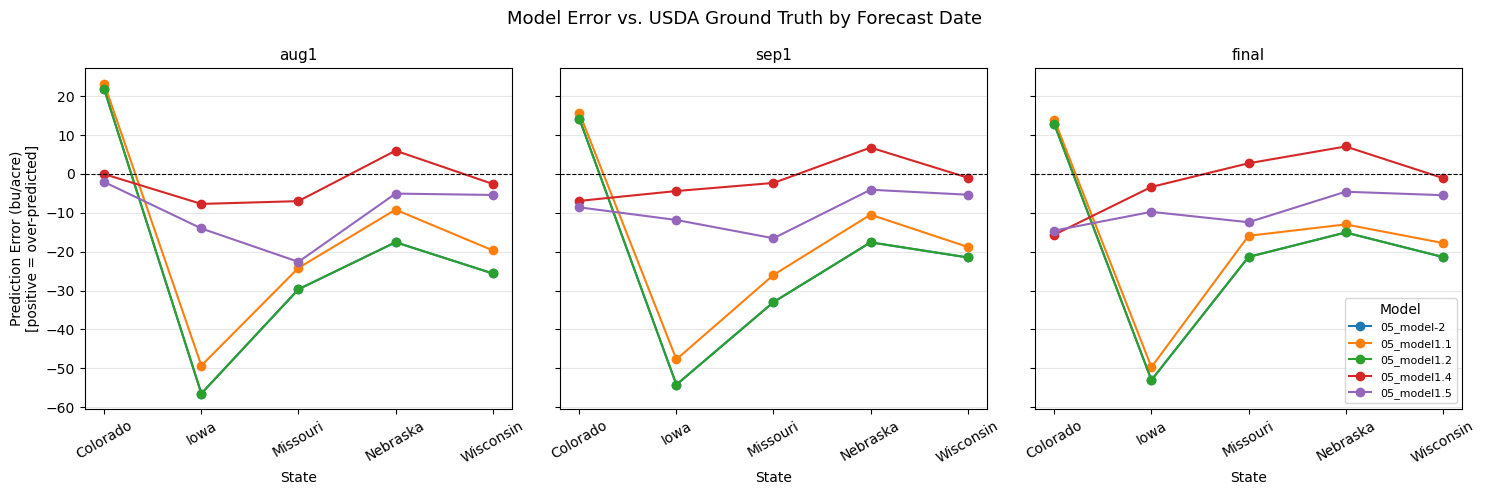

Saved: ../outputs/error_by_state_and_date.png


In [7]:
# ── PLOT 1: Error by state, faceted by forecast date ──────────────────────────
versions = sorted(preds['model_version'].unique())
colors   = plt.cm.tab10.colors

fig, axes = plt.subplots(
    1, len(SCORED_DATES),
    figsize=(5 * len(SCORED_DATES), 5),
    sharey=True
)

for ax, fd in zip(axes, SCORED_DATES):
    sub = merged[(merged['forecast_date'] == fd)].dropna(subset=['usda_yield'])
    for idx, ver in enumerate(versions):
        v = sub[sub['model_version'] == ver].sort_values('state')
        ax.plot(
            v['state'], v['error'],
            marker='o', label=ver, color=colors[idx % len(colors)]
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(fd, fontsize=11)
    ax.set_xlabel('State')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Prediction Error (bu/acre)\n[positive = over-predicted]')
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, title='Model', fontsize=8, loc='best')

plt.suptitle('Model Error vs. USDA Ground Truth by Forecast Date', fontsize=13)
plt.tight_layout()

out_path = OUT_DIR / "error_by_state_and_date.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

/tmp/ipykernel_201349/2591444827.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = summary.pivot_table(


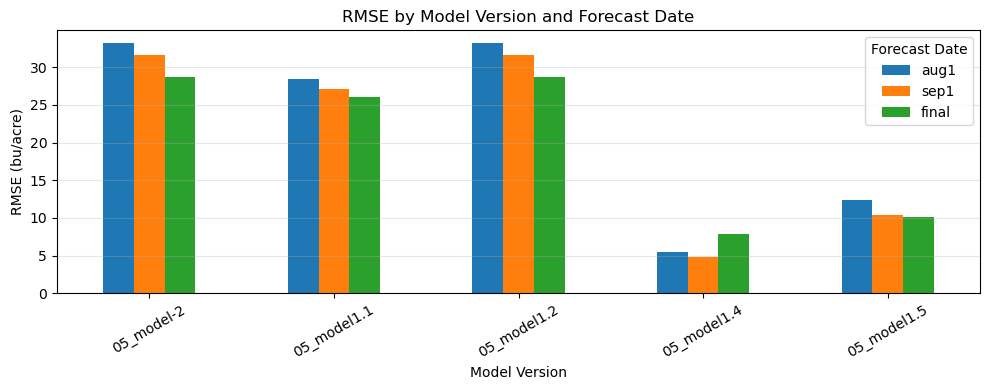

Saved: ../outputs/rmse_progression.png


In [8]:
# ── PLOT 2: RMSE progression across model versions ────────────────────────────
pivot = summary.pivot_table(
    index='model_version', columns='forecast_date', values='rmse'
)[SCORED_DATES]

ax = pivot.plot(kind='bar', figsize=(max(6, len(versions) * 2), 4), rot=30)
ax.set_ylabel('RMSE (bu/acre)')
ax.set_xlabel('Model Version')
ax.set_title('RMSE by Model Version and Forecast Date')
ax.legend(title='Forecast Date')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

out_path = OUT_DIR / "rmse_progression.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

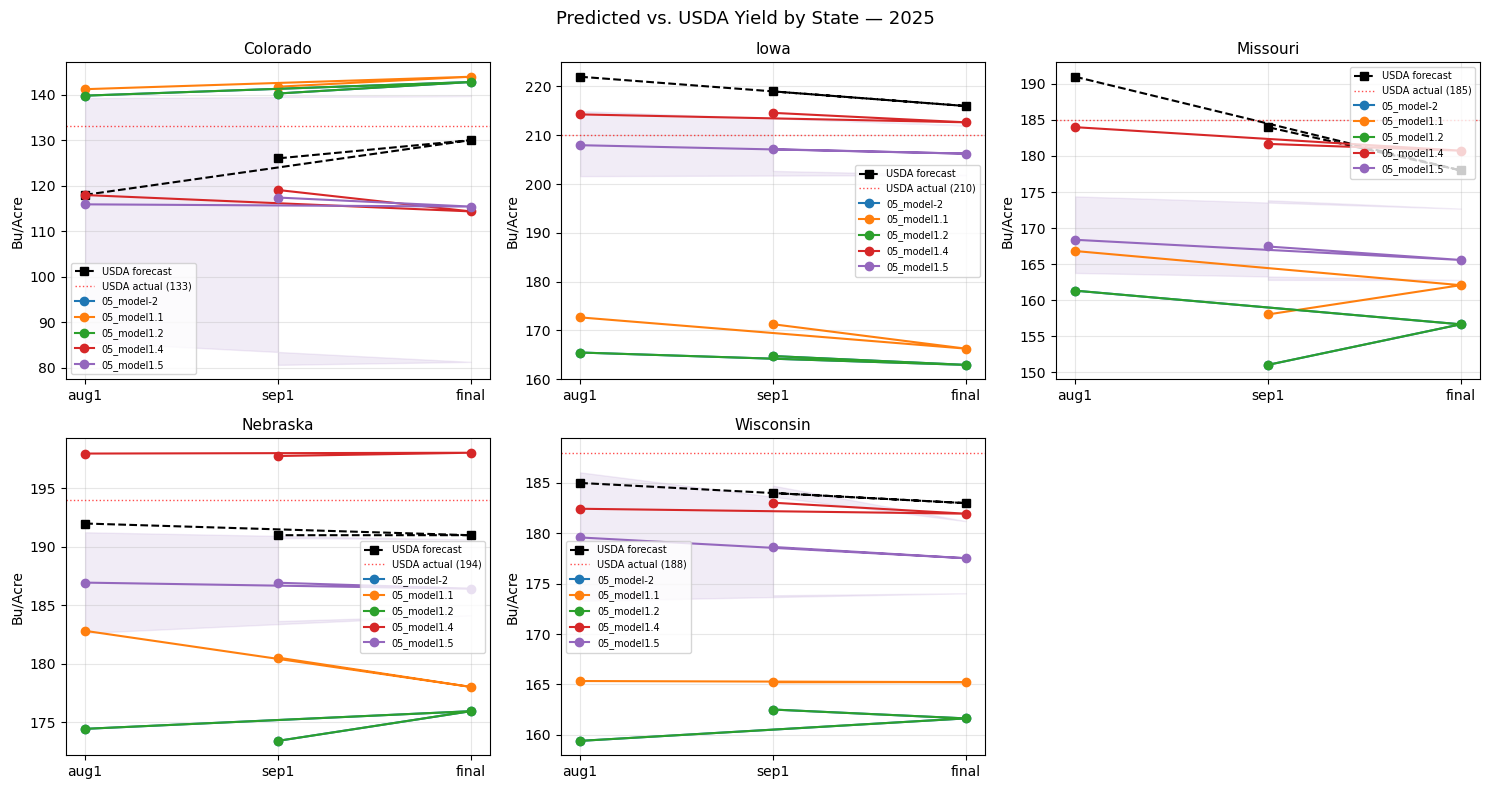

Saved: ../outputs/predicted_vs_usda_by_state.png


In [9]:
# ── PLOT 3: Predicted vs. USDA, one panel per state ───────────────────────────
# Shows the full forecast trajectory (aug1 → sep1 → final) for each model version
# against the USDA forecast at the same dates, and the true end-of-season actual.

date_x = {fd: i for i, fd in enumerate(SCORED_DATES)}
usda_scored = usda[usda['forecast_date'].isin(SCORED_DATES)].sort_values('forecast_date')

ncols = 3
nrows = -(-len(STATES) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, state in enumerate(STATES):
    ax = axes[i]

    # USDA forecasts at each scored date
    u = usda_scored[usda_scored['state'] == state].sort_values('forecast_date')
    xs = [date_x[fd] for fd in u['forecast_date']]
    ax.plot(xs, u['usda_yield'], 'ks--', linewidth=1.5, markersize=6, label='USDA forecast')

    # True end-of-season actual (horizontal reference)
    actual_row = actuals[actuals['state'] == state]
    if not actual_row.empty:
        actual_val = actual_row['usda_actual'].values[0]
        ax.axhline(actual_val, color='red', linewidth=1, linestyle=':', alpha=0.7,
                   label=f'USDA actual ({actual_val:.0f})')

    # Each model version
    for idx, ver in enumerate(versions):
        sub = merged[
            (merged['model_version'] == ver) &
            (merged['state'] == state) &
            (merged['forecast_date'].isin(SCORED_DATES))
        ].sort_values('forecast_date')
        xs_m = [date_x[fd] for fd in sub['forecast_date']]
        ax.plot(xs_m, sub['predicted_yield'],
                marker='o', linewidth=1.5,
                color=colors[idx % len(colors)], label=ver)
        # CI shading for the latest model version only to avoid visual clutter
        if ver == versions[-1]:
            ax.fill_between(
                xs_m, sub['ci_lower'], sub['ci_upper'],
                alpha=0.12, color=colors[idx % len(colors)]
            )

    ax.set_title(state, fontsize=11)
    ax.set_xticks(list(date_x.values()))
    ax.set_xticklabels(list(date_x.keys()))
    ax.set_ylabel('Bu/Acre')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

# Hide any unused subplots
for j in range(len(STATES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predicted vs. USDA Yield by State — 2025', fontsize=13)
plt.tight_layout()

out_path = OUT_DIR / "predicted_vs_usda_by_state.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

In [10]:
# ── FULL DIFF TABLE (saved to CSV for easy external review) ───────────────────
diff = merged[display_cols].sort_values(['model_version', 'forecast_date', 'state'])

out_path = OUT_DIR / "full_diff.csv"
diff.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print("\nDone. Outputs written:")
for f in [
    "comparison_summary.csv",
    "full_diff.csv",
    "error_by_state_and_date.png",
    "rmse_progression.png",
    "predicted_vs_usda_by_state.png",
]:
    print(f"  outputs/{f}")

Saved: ../outputs/full_diff.csv

Done. Outputs written:
  outputs/comparison_summary.csv
  outputs/full_diff.csv
  outputs/error_by_state_and_date.png
  outputs/rmse_progression.png
  outputs/predicted_vs_usda_by_state.png
